Testing Cover Letter Nodes 

In [1]:
from src.cover_letter.nodes import extract_keywords_node

mock_state = {
    "job_description": "We are seeking a Cloud Infrastructure Engineer with AWS, Linux, and Docker experience..."
}

# Test just the parser
parsed_result = extract_keywords_node(mock_state)
print(parsed_result)

{'extracted_keywords': ['AWS', 'Linux', 'Docker']}


Testing Resume Nodes 

In [2]:
from src.resume.nodes import extract_keywords_node

mock_resume_state = {
    "job_description": "We are seeking a Cloud Infrastructure Engineer with AWS, Linux, and Docker experience..."
}

# Test the deterministic parser for the resume pipeline
parsed_result = extract_keywords_node(mock_resume_state)
print("Extracted Keywords:", parsed_result.get("extracted_keywords"))
print("Initialized State Defaults:", {k: v for k, v in parsed_result.items() if k != "extracted_keywords"})

Extracted Keywords: ['AWS', 'Linux', 'Docker', 'Cloud Infrastructure', 'Infrastructure as Code', 'Networking', 'CI/CD', 'Kubernetes', 'Terraform', 'Python', 'Bash', 'DevOps', 'Systems Administration', 'Monitoring', 'Security']
Initialized State Defaults: {'iteration_count': 0, 'ats_match_score': 0.0, 'evaluation_feedback': ''}


Visualising Cover Letter Architecture 

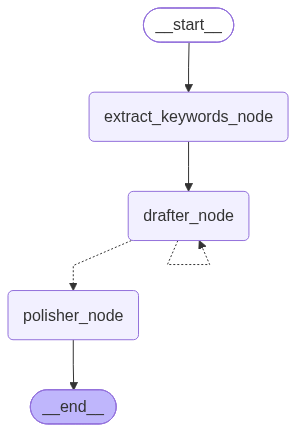

In [3]:
from IPython.display import Image, display
from src.cover_letter.graph import compiled_graph

display(Image(compiled_graph.get_graph().draw_mermaid_png()))

Visualising Resume Architecture 

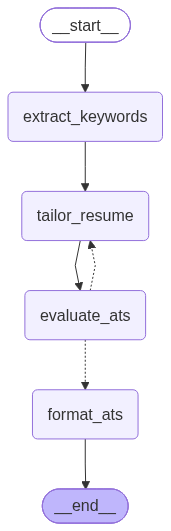

In [4]:
from IPython.display import Image, display
from src.resume.graph import resume_app

# Render the resume graph visual topology (nodes, feedback loop, edges)
display(Image(resume_app.get_graph().draw_mermaid_png()))

Cover Letter Graph Stream  

In [5]:
inputs = {
    "resume_text": "Experienced in cloud infrastructure and team enablement...",
    "job_description": "Looking for AWS and system design skills...",
    "min_words": 250,
    "max_words": 400
}
config = {"configurable": {"thread_id": "test-run-1"}}

# Inspect each step as it completes
for event in compiled_graph.stream(inputs, config=config):
    for node_name, node_output in event.items():
        print(f"--- Node Executed: {node_name} ---")
        if "keyword_score" in node_output:
            print(f"Score: {node_output['keyword_score']}")
            print(f"Critique: {node_output['critique']}")

--- Node Executed: extract_keywords_node ---
--- Node Executed: drafter_node ---
Score: 1.0
Critique: Word count is within the target range (250 words; target: 250-400).
Keyword Coverage: 100%.

--- Node Executed: polisher_node ---


Resume Graph Stream 

In [6]:
from src.resume.graph import resume_app

inputs = {
    "master_resume": (
        "Experienced Cloud Engineer skilled in Linux, Docker containerization, and automated workflows. "
        "Led system design reviews and improved service availability across platforms."
    ),
    "job_description": (
        "We are looking for a Senior Platform Engineer with strong Linux, Docker, AWS, "
        "and system design skills to lead our platform reliability efforts."
    )
}

config = {"configurable": {"thread_id": "resume-test-run-1"}}

# Inspect each step as it streams through the loop
for event in resume_app.stream(inputs, config=config):
    for node_name, node_output in event.items():
        print(f"\n--- Node Executed: {node_name} ---")
        
        # Display extraction output
        if "extracted_keywords" in node_output:
            print("Extracted Keywords:", node_output["extracted_keywords"])
            
        # Display evaluation metrics and feedback
        if "ats_match_score" in node_output:
            print(f"ATS Match Score: {node_output['ats_match_score']:.2f}")
            print(f"Critique:\n{node_output.get('evaluation_feedback', '')}")
            
        # Display current iteration count
        if "iteration_count" in node_output:
            print(f"Iteration Count: {node_output['iteration_count']}")
            
        # Display final ATS formatted resume
        if "final_ats_resume" in node_output:
            print("\n=== Final Tailored ATS Resume ===\n")
            print(node_output["final_ats_resume"])


--- Node Executed: extract_keywords ---
Extracted Keywords: ['Senior Platform Engineer', 'Linux', 'Docker', 'AWS', 'system design', 'platform reliability', 'infrastructure engineering', 'senior-level experience']
ATS Match Score: 0.00
Critique:

Iteration Count: 0

--- Node Executed: tailor_resume ---
Iteration Count: 1

--- Node Executed: evaluate_ats ---
ATS Match Score: 0.99
Critique:
The resume strongly matches all target keywords, including Senior Platform Engineer, Linux, Docker, AWS, system design, platform reliability, infrastructure engineering, and senior-level experience. To improve further, you could add more concrete achievements, metrics, or scope to strengthen impact.

--- Node Executed: format_ats ---

=== Final Tailored ATS Resume ===

Summary

Experienced Senior Platform Engineer with senior-level experience in Linux, Docker, and AWS. Skilled in infrastructure engineering, system design, and platform reliability, with a focus on improving service availability and sup